# Hamiltonian and underdamped dynamics: geometry in phase space

Hamiltonian methods augment position with momentum and use nearly conservative
trajectories to propose distant moves. Underdamped Langevin adds friction and exact
Ornstein--Uhlenbeck momentum noise. Numerical integration quality, mass-matrix choice,
and Metropolis correction determine whether those long moves are useful or merely
dramatic.

**Output semantics.** HMC and metropolized underdamped dynamics are exact-invariant
Markov chains. Raw leapfrog and BAOAB are numerical dynamics and can exhibit finite-step
error or bias.


In [1]:
import importlib.metadata
import os

import matplotlib.pyplot as plt
import numpy as np

from sampler_lab.dynamics import (
    HamiltonianSystem,
    MassMatrix,
    PhaseSpaceState,
    finite_difference_jacobian,
    gaussian_hamiltonian_analysis,
    gaussian_hamiltonian_frequencies,
    leapfrog_integrate,
    leapfrog_map,
    leapfrog_reversibility_error,
    symplecticity_error,
    volume_preservation_error,
)
from sampler_lab.experiments import (
    run_hamiltonian_gaussian_experiment,
    run_xy_dynamics_experiment,
)
from sampler_lab.models import GaussianTarget

QUICK_MODE = os.environ.get("SAMPLER_LAB_NOTEBOOK_MODE") == "quick"
SEED = 2022
FIGURE_COUNT = 0


def finish_figure(fig):
    global FIGURE_COUNT
    fig.tight_layout()
    plt.show()
    plt.close(fig)
    FIGURE_COUNT += 1


print("sampler-lab", importlib.metadata.version("sampler-lab"))
print("execution mode:", "quick" if QUICK_MODE else "publication")
print("master seed:", SEED)

sampler-lab 0.12.0
execution mode: publication
master seed: 2022


## 1. Mass convention and a minimal leapfrog trajectory

Sampler Lab stores the momentum covariance $M$, so

$$
H(q,p)=-\log\pi(q)+\tfrac12p^\mathsf{T}M^{-1}p,
\qquad p\sim N(0,M).
$$

Leapfrog alternates half momentum kicks and full position drifts. It is reversible and
volume preserving in exact arithmetic, but it conserves a nearby modified Hamiltonian
rather than the exact energy.


In [2]:
phase_target = GaussianTarget([0.0, 0.0], [[1.0, 0.65], [0.65, 1.0]])
phase_mass = MassMatrix.identity(2)
phase_system = HamiltonianSystem(phase_target, phase_mass)
phase = PhaseSpaceState([1.6, -0.8], [0.1, 1.2])
phase_step = 0.08
n_phase_steps = 180 if QUICK_MODE else 600
positions = [phase.position.copy()]
momenta = [phase.momentum.copy()]
energies = [phase_system.energy(phase)]
for _ in range(n_phase_steps):
    phase = leapfrog_integrate(phase_system, phase, phase_step, 1).final_state
    positions.append(phase.position.copy())
    momenta.append(phase.momentum.copy())
    energies.append(phase_system.energy(phase))
positions = np.asarray(positions)
momenta = np.asarray(momenta)
energies = np.asarray(energies)
print("maximum absolute energy error:", float(np.max(np.abs(energies - energies[0]))))

maximum absolute energy error: 0.018893310702110533


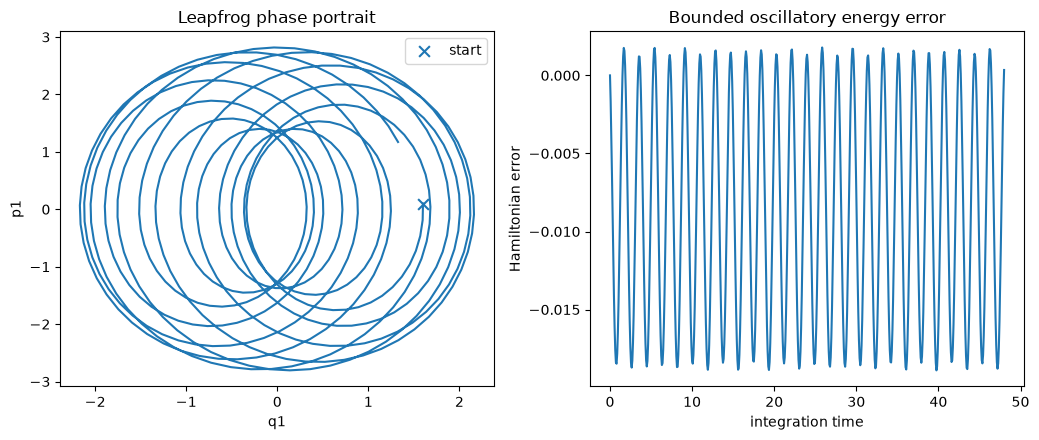

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
axes[0].plot(positions[:, 0], momenta[:, 0])
axes[0].scatter(positions[0, 0], momenta[0, 0], marker="x", s=60, label="start")
axes[0].set_xlabel("q1")
axes[0].set_ylabel("p1")
axes[0].set_title("Leapfrog phase portrait")
axes[0].legend()
axes[1].plot(phase_step * np.arange(energies.size), energies - energies[0])
axes[1].set_xlabel("integration time")
axes[1].set_ylabel("Hamiltonian error")
axes[1].set_title("Bounded oscillatory energy error")
finish_figure(fig)

## 2. Reversibility, volume, and symplecticity are different checks

A small energy error does not itself prove that an integrator is reversible or
symplectic. The package exposes separate diagnostics. We keep total trajectory time
approximately fixed while varying the step size.


finite-difference volume error: 1.0393644278572367e-10
finite-difference symplectic residual: 2.684938704385717e-10


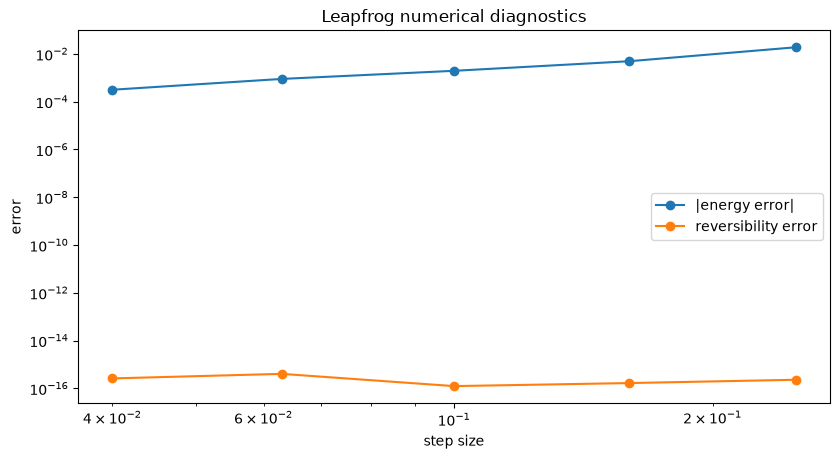

In [4]:
diagnostic_initial = PhaseSpaceState([0.7, -0.4], [0.9, 0.3])
diagnostic_steps = np.array([0.25, 0.16, 0.10, 0.063, 0.04])
diagnostic_rows = []
for step in diagnostic_steps:
    n_steps = max(1, round(1.6 / step))
    result = leapfrog_integrate(phase_system, diagnostic_initial, step, n_steps)
    reverse_error = leapfrog_reversibility_error(
        phase_system,
        diagnostic_initial,
        step,
        n_steps,
    )
    diagnostic_rows.append((step, abs(result.energy_error), reverse_error))

map_step = 0.1
map_steps = 8
jacobian = finite_difference_jacobian(
    lambda state: leapfrog_map(phase_system, state, map_step, map_steps),
    diagnostic_initial.as_array(),
)
volume_error = volume_preservation_error(jacobian)
symplectic_error = symplecticity_error(jacobian)
print("finite-difference volume error:", volume_error)
print("finite-difference symplectic residual:", symplectic_error)

fig, ax = plt.subplots(figsize=(8.5, 4.7))
diagnostic_rows = np.asarray(diagnostic_rows)
ax.loglog(diagnostic_rows[:, 0], diagnostic_rows[:, 1], "o-", label="|energy error|")
ax.loglog(diagnostic_rows[:, 0], diagnostic_rows[:, 2], "o-", label="reversibility error")
ax.set_xlabel("step size")
ax.set_ylabel("error")
ax.legend()
ax.set_title("Leapfrog numerical diagnostics")
finish_figure(fig)

## 3. Mass matrices set Hamiltonian frequencies

For a Gaussian target with precision $\Lambda$, choosing $M=\Lambda$ equalizes the
normal-mode frequencies. Choosing the covariance does not. Equal frequencies permit a
step size that does not shrink with the target condition number.


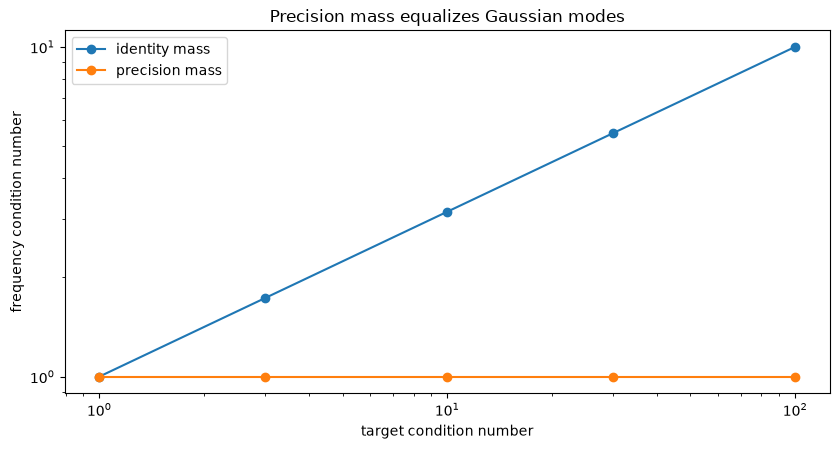

In [5]:
mass_condition_numbers = np.array([1.0, 3.0, 10.0, 30.0, 100.0])
frequency_rows = []
for condition in mass_condition_numbers:
    covariance = np.diag([1.0, 1.0 / condition])
    target = GaussianTarget([0.0, 0.0], covariance)
    identity_frequencies = gaussian_hamiltonian_frequencies(target)
    precision_frequencies = gaussian_hamiltonian_frequencies(
        target,
        MassMatrix(target.precision_matrix),
    )
    frequency_rows.append(
        (
            condition,
            np.max(identity_frequencies) / np.min(identity_frequencies),
            np.max(precision_frequencies) / np.min(precision_frequencies),
        )
    )
frequency_rows = np.asarray(frequency_rows)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(frequency_rows[:, 0], frequency_rows[:, 1], "o-", label="identity mass")
ax.plot(frequency_rows[:, 0], frequency_rows[:, 2], "o-", label="precision mass")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("target condition number")
ax.set_ylabel("frequency condition number")
ax.legend()
ax.set_title("Precision mass equalizes Gaussian modes")
finish_figure(fig)

## 4. CLI-matched Gaussian comparison

This reproduces the Gaussian family and seed used by
`sampler-lab-hamiltonian-demo`. We compare identity-mass HMC, precision-mass HMC,
unadjusted BAOAB, and metropolized underdamped dynamics. Cost is reported per gradient
evaluation rather than per stored state.


In [6]:
gaussian_rows = run_hamiltonian_gaussian_experiment(
    condition_numbers=(1.0, 10.0, 100.0),
    n_samples=1500 if QUICK_MODE else 5000,
    burn_in=300 if QUICK_MODE else 800,
    trajectory_time=1.0,
    step_fraction=0.25,
    friction=1.0,
    seed=SEED,
)
for row in gaussian_rows:
    print(
        row.condition_number,
        row.method,
        "accept=",
        None if row.acceptance_rate is None else round(row.acceptance_rate, 4),
        "IAT=",
        round(row.empirical_iat, 3),
        "ESS/1k grad=",
        round(row.ess_per_thousand_gradients, 3),
    )

1.0 HMC identity mass accept= 0.9709 IAT= 2.891 ESS/1k grad= 99.411
1.0 HMC precision mass accept= 0.971 IAT= 3.914 ESS/1k grad= 73.415
1.0 BAOAB precision mass accept= None IAT= 9.935 ESS/1k grad= 43.384
1.0 Metropolized underdamped accept= 0.9847 IAT= 4.907 ESS/1k grad= 87.846
10.0 HMC identity mass accept= 0.9976 IAT= 3.773 ESS/1k grad= 32.643
10.0 HMC precision mass accept= 0.9721 IAT= 3.176 ESS/1k grad= 90.489
10.0 BAOAB precision mass accept= None IAT= 10.019 ESS/1k grad= 43.024
10.0 Metropolized underdamped accept= 0.9857 IAT= 4.773 ESS/1k grad= 90.305
100.0 HMC identity mass accept= 0.9859 IAT= 4.032 ESS/1k grad= 10.181
100.0 HMC precision mass accept= 0.9767 IAT= 3.45 ESS/1k grad= 83.286
100.0 BAOAB precision mass accept= None IAT= 10.27 ESS/1k grad= 41.971
100.0 Metropolized underdamped accept= 0.9826 IAT= 4.848 ESS/1k grad= 88.905


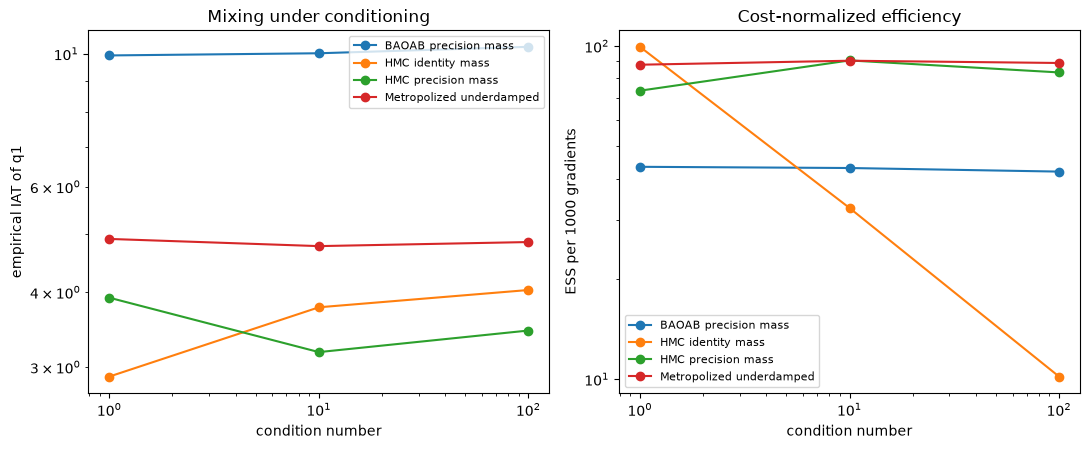

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6))
methods = sorted({row.method for row in gaussian_rows})
for method in methods:
    selected = [row for row in gaussian_rows if row.method == method]
    axes[0].plot(
        [row.condition_number for row in selected],
        [row.empirical_iat for row in selected],
        "o-",
        label=method,
    )
    axes[1].plot(
        [row.condition_number for row in selected],
        [row.ess_per_thousand_gradients for row in selected],
        "o-",
        label=method,
    )
for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("condition number")
    ax.legend(fontsize=8)
axes[0].set_ylabel("empirical IAT of q1")
axes[1].set_ylabel("ESS per 1000 gradients")
axes[0].set_title("Mixing under conditioning")
axes[1].set_title("Cost-normalized efficiency")
finish_figure(fig)

## 5. Underdamped dynamics on a compact target

A one-site XY model is a von Mises distribution. Its exact circular response supplies a
non-Gaussian benchmark for HMC, BAOAB, and metropolized underdamped dynamics. Position
wrapping keeps angles on the torus.


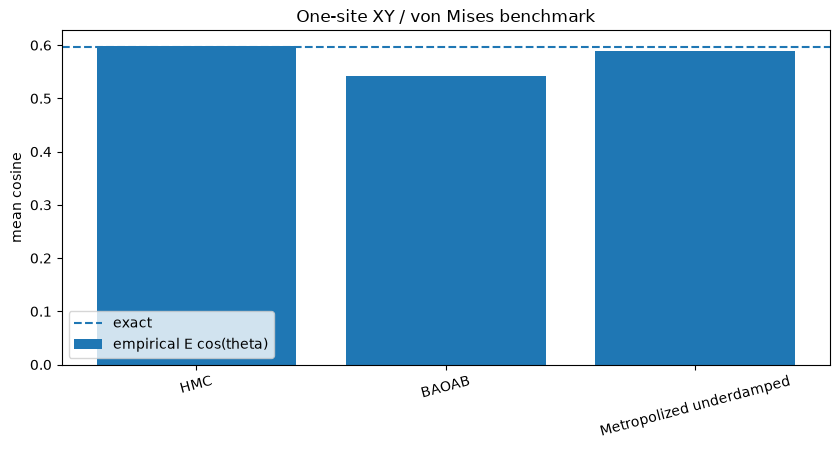

HMC absolute error= 0.00185 IAT= 1.755
BAOAB absolute error= 0.05321 IAT= 16.667
Metropolized underdamped absolute error= 0.00685 IAT= 7.505


In [8]:
xy_rows = run_xy_dynamics_experiment(
    n_samples=1500 if QUICK_MODE else 5000,
    burn_in=300 if QUICK_MODE else 800,
    concentration=1.5,
    seed=SEED + 1,
)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
x_positions = np.arange(len(xy_rows))
ax.bar(x_positions, [row.mean_cosine for row in xy_rows], label="empirical E cos(theta)")
ax.axhline(xy_rows[0].exact_mean_cosine, linestyle="--", label="exact")
ax.set_xticks(x_positions, [row.method for row in xy_rows], rotation=15)
ax.set_ylabel("mean cosine")
ax.legend()
ax.set_title("One-site XY / von Mises benchmark")
finish_figure(fig)
for row in xy_rows:
    print(
        row.method,
        "absolute error=",
        round(row.absolute_error, 5),
        "IAT=",
        round(row.empirical_iat, 3),
    )

## 6. Controlled failure: leapfrog beyond its stability threshold

On a Gaussian mode of frequency $\omega$, leapfrog requires $h\omega<2$. The package
computes the exact phase-map spectral radius, so instability can be diagnosed before a
chain is launched.


maximum stable step: 0.2
unstable step: 0.21000000000000002
unstable spectral radius: 12.421117556238155


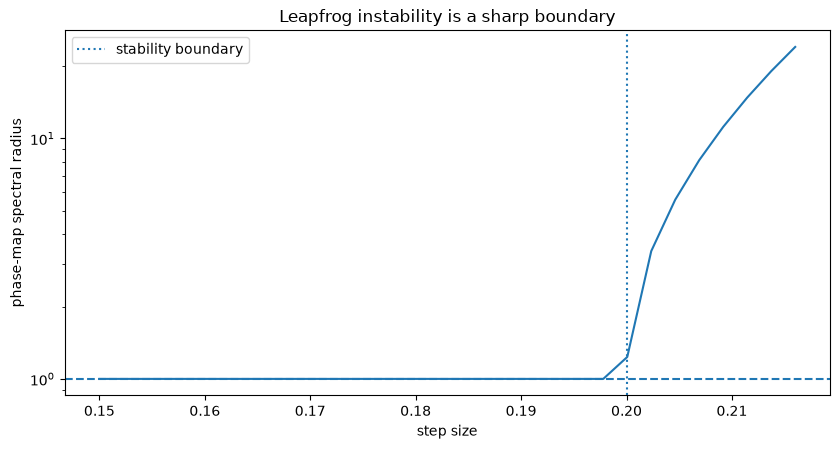

In [9]:
failure_target = GaussianTarget([0.0, 0.0], np.diag([1.0, 0.01]))
stable = gaussian_hamiltonian_analysis(failure_target, 0.15, 4)
unstable_step = 1.05 * stable.maximum_stable_step_size
unstable = gaussian_hamiltonian_analysis(failure_target, unstable_step, 4)
print("maximum stable step:", stable.maximum_stable_step_size)
print("unstable step:", unstable_step)
print("unstable spectral radius:", unstable.leapfrog_spectral_radius)

steps = np.linspace(0.15, 1.08 * stable.maximum_stable_step_size, 30)
radii = [
    gaussian_hamiltonian_analysis(failure_target, float(step), 4).leapfrog_spectral_radius
    for step in steps
]
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(steps, radii)
ax.axhline(1.0, linestyle="--")
ax.axvline(stable.maximum_stable_step_size, linestyle=":", label="stability boundary")
ax.set_yscale("log")
ax.set_xlabel("step size")
ax.set_ylabel("phase-map spectral radius")
ax.legend()
ax.set_title("Leapfrog instability is a sharp boundary")
finish_figure(fig)

## When to use Hamiltonian or underdamped methods

- HMC is attractive when gradients are available and long, coherent moves can traverse
  the target more cheaply than a random walk.
- Tune mass and coordinates before obsessing over trajectory length; poor geometry makes
  every integrator work harder.
- BAOAB is rejection-free but approximate at fixed step size. Metropolized underdamped
  dynamics restores exact invariance and must flip momentum on rejection.
- Monitor energy error, reversibility, acceptance, IAT, and gradient-normalized ESS.

Further experiments: randomize trajectory lengths, vary momentum persistence, compare
exact and leapfrog Gaussian flow matrices, or study toroidal trajectories in a larger XY
lattice.


In [10]:
stiff_identity = next(
    row
    for row in gaussian_rows
    if row.condition_number == 100.0 and row.method == "HMC identity mass"
)
stiff_precision = next(
    row
    for row in gaussian_rows
    if row.condition_number == 100.0 and row.method == "HMC precision mass"
)
max_xy_error = max(row.absolute_error for row in xy_rows)
print("volume error:", volume_error)
print("symplectic error:", symplectic_error)
print("largest XY moment error:", max_xy_error)

assert volume_error < 2e-5
assert symplectic_error < 3e-5
assert frequency_rows[-1, 1] > 8.0
assert frequency_rows[-1, 2] < 1.000001
assert stiff_precision.empirical_iat < stiff_identity.empirical_iat
assert max_xy_error < (0.14 if QUICK_MODE else 0.08)
assert unstable.leapfrog_spectral_radius > 1.0
assert FIGURE_COUNT >= 6
print(f"completed Hamiltonian notebook with {FIGURE_COUNT} figures")

volume error: 1.0393644278572367e-10
symplectic error: 2.684938704385717e-10
largest XY moment error: 0.053207802073459876
completed Hamiltonian notebook with 6 figures
